# 🧬 Catálogo de Datos Genómicos — OXOR / GENO-MAP

**Objetivo:** Documentar de forma reproducible el universo de datasets disponibles en el CIP Dataverse,
la selección curada para este proyecto, el status de acceso, la estructura de cada archivo,
y las métricas de calidad.

**Output principal:** Este notebook genera `data/DATA_CATALOG.md` como artefacto legible para que
otros agentes/modelos accedan a la información sin parsear el `.ipynb`.

> **Dependencias:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `requests`  
> **Kernel:** Python ≥ 3.10

In [1]:
import pandas as pd
import numpy as np
import json
import subprocess
import csv
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path("../data")
assert DATA_DIR.exists(), f"No se encontró {DATA_DIR.resolve()}"

with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

with open(DATA_DIR / "cipotato_datasets_latest100.json") as f:
    universo = json.load(f)

# Acumulador para el markdown final
md_sections: list[str] = []

print(f"✅ Cargado: {len(universo)} datasets del universo CIP, {sum(len(v) for v in metadata.values())} datasets curados")

✅ Cargado: 100 datasets del universo CIP, 11 datasets curados


## 1. Universo de Datasets — CIP Dataverse

El archivo `cipotato_datasets_latest100.json` contiene los **100 datasets más recientes** publicados en
[data.cipotato.org](https://data.cipotato.org). La mayoría son datos de ensayos de campo para papa;
solo un subconjunto corresponde a **genotipado molecular** (DArT/DArTSeq) de cultivos andinos.

In [2]:
# Crear tabla del universo CIP
df_universo = pd.DataFrame(universo)
df_universo["doi_code"] = df_universo["url"].str.extract(r"/P3/(\w+)")
df_universo["fecha"] = pd.to_datetime(df_universo["published_at"]).dt.date
df_universo["n_autores"] = df_universo["authors"].apply(len)

# Clasificar por keywords en título/descripción
genotyping_kw = r"(?i)genotyp|DArT|SNP|SilicoDArT|genetic\s+diversity|amplicon|allele|marker"
df_universo["es_genotipado"] = (
    df_universo["title"].str.contains(genotyping_kw, regex=True, na=False)
    | df_universo["description"].str.contains(genotyping_kw, regex=True, na=False)
)

# DOIs que están en nuestro metadata.json curado
curated_dois = set()
for datasets in metadata.values():
    for ds in datasets:
        code = ds["doi"].split("/P3/")[-1] if "/P3/" in ds["doi"] else ""
        curated_dois.add(code)

df_universo["en_catalogo"] = df_universo["doi_code"].isin(curated_dois)

print(f"Total datasets en CIP Dataverse (últimos 100): {len(df_universo)}")
print(f"  → Relacionados con genotipado: {df_universo['es_genotipado'].sum()}")
print(f"  → Presentes en nuestro catálogo curado: {df_universo['en_catalogo'].sum()}")
print()

# Mostrar los de genotipado resaltando los curados
cols_show = ["doi_code", "title", "fecha", "n_autores", "en_catalogo"]
display(
    df_universo[df_universo["es_genotipado"]][cols_show]
    .sort_values("en_catalogo", ascending=False)
    .reset_index(drop=True)
    .style.apply(
        lambda row: ["background: #d4edda" if row["en_catalogo"] else "" for _ in row],
        axis=1,
    )
)

# Sección para el markdown
geno_df = df_universo[df_universo["es_genotipado"]][["doi_code", "title", "fecha", "en_catalogo"]]
md_sections.append("## 1. Universo CIP Dataverse\n")
md_sections.append(f"- **Total datasets escaneados:** {len(df_universo)}\n")
md_sections.append(f"- **Relacionados con genotipado:** {df_universo['es_genotipado'].sum()}\n")
md_sections.append(f"- **Seleccionados para este proyecto:** {df_universo['en_catalogo'].sum()}\n\n")
md_sections.append("### Datasets de genotipado detectados\n\n")
md_sections.append(geno_df.to_markdown(index=False) + "\n\n")

Total datasets en CIP Dataverse (últimos 100): 100
  → Relacionados con genotipado: 20
  → Presentes en nuestro catálogo curado: 11



,doi_code,title,fecha,n_autores,en_catalogo
0,CD01KI,Dataset for: High density genotyping of cultivated ullucus genebank accessions using SNP markers from DArTseq,2026-01-27,4,True
1,JW6UOC,Dataset for: High density genotyping of cultivated yacon genebank accessions using SNP markers from DArTseq,2026-01-27,5,True
2,D3XEEH,Dataset for: Genotyping of sweetpotato genebank accessions using amplicon-based targeted markers (DArTag),2025-12-31,2,True
3,TFOJNZ,Dataset for: Genotypic Dataset of In Situ Native Mashua Varieties from the Andenes de Cuyocuyo Agrobiodiversity Zone using SilicoDArT markers,2026-01-27,13,True
4,M613LS,Dataset for: Genotypic Dataset of In Situ Native Oca Varieties from the Andenes de Cuyocuyo Agrobiodiversity Zone using SilicoDArT markers,2026-01-27,13,True
5,FYYLLO,Dataset for: Genotypic Dataset of In Situ Native Ulluco Varieties from the Andenes de Cuyocuyo Agrobiodiversity Zone using SilicoDArT markers,2026-01-27,13,True
6,IXXW5N,Dataset for: High density genotyping of cultivated ullucus genebank accessions using SilicoDArT markers,2026-01-27,4,True
7,5KHIK4,Dataset for: High density genotyping of cultivated yacon genebank accessions using SilicoDArT markers,2026-01-27,5,True
8,S2IMOS,Replication data for: Revealing the genetic diversity in the global ex situ sweetpotato collection with next generation sequencing technologies.,2025-12-17,2,True
9,UBDJ44,Dataset for: Genotyping of sweetpotato genebank accessions using low-density DArTSeq markers,2026-01-28,2,True


## 2. Catálogo Curado (`metadata.json`)

De los ~100 datasets del CIP Dataverse, **11 son relevantes** para genotipado de cultivos andinos.
Se organizan por cultivo. Cada entrada indica si el dataset es de acceso libre o restringido,
y si ya fue descargado localmente.

- **Descargados:** datasets con carpeta local y archivos CSV disponibles
- **Accesible:** dataset público sin restricción, pero aún no descargado
- **Restringido:** dataset publicado en el Dataverse pero que requiere permisos del CIP para descarga

In [3]:
# Construir tabla del catálogo curado
rows = []
for crop, datasets in metadata.items():
    for ds in datasets:
        restricted = ds.get("restricted", False)
        folder = ds.get("folder")
        folder_exists = (DATA_DIR / folder).exists() if folder else False
        
        if restricted:
            status = "🔒 Restringido"
        elif folder_exists:
            status = "✅ Descargado"
        elif folder:
            status = "⚠️ Carpeta no encontrada"
        else:
            status = "🌐 Accesible (no descargado)"
        
        rows.append({
            "Cultivo": crop,
            "Tipo": ds.get("type", ""),
            "DOI": ds.get("doi", ""),
            "Carpeta": folder or "—",
            "Status": status,
        })

catalogo = pd.DataFrame(rows)

print(f"Total datasets catalogados: {len(catalogo)}")
print(f"Cultivos: {catalogo['Cultivo'].nunique()} — {', '.join(catalogo['Cultivo'].unique())}")
print()

status_counts = catalogo["Status"].value_counts()
for s, n in status_counts.items():
    print(f"  {s}: {n}")
print()

display(
    catalogo.style.apply(
        lambda row: [
            "background: #d4edda" if "Descargado" in row["Status"]
            else "background: #fff3cd" if "Accesible" in row["Status"]
            else "background: #f8d7da" if "Restringido" in row["Status"]
            else ""
            for _ in row
        ],
        axis=1,
    )
)

# Para el markdown
md_sections.append("## 2. Catálogo Curado (metadata.json)\n\n")
md_sections.append(f"**{len(catalogo)} datasets** de **{catalogo['Cultivo'].nunique()} cultivos**: {', '.join(catalogo['Cultivo'].unique())}\n\n")
md_sections.append("| Status | Cantidad |\n|--------|----------|\n")
for s, n in status_counts.items():
    md_sections.append(f"| {s} | {n} |\n")
md_sections.append("\n")
md_sections.append(catalogo[["Cultivo", "Tipo", "DOI", "Status"]].to_markdown(index=False) + "\n\n")

Total datasets catalogados: 11
Cultivos: 5 — Sweetpotato, Yacon, Ulluco, Oca, Mashua

  🔒 Restringido: 8
  ✅ Descargado: 3



,Cultivo,Tipo,DOI,Carpeta,Status
0,Sweetpotato,low-density DArTSeq,https://doi.org/10.21223/P3/UBDJ44,10.21223P3UBDJ44_LowDensity,✅ Descargado
1,Sweetpotato,DArTag 3.1K amplicones,https://doi.org/10.21223/P3/D3XEEH,—,🔒 Restringido
2,Sweetpotato,diversidad global NGS,https://doi.org/10.21223/P3/S2IMOS,10.21223P30BVZYY_Genetic_diversity,✅ Descargado
3,Sweetpotato,wild relatives,https://doi.org/10.21223/P3/3VYY8C,10.21223P33VYY8C_Wild,✅ Descargado
4,Yacon,SNP,https://doi.org/10.21223/P3/JW6UOC,—,🔒 Restringido
5,Yacon,SilicoDArT,https://doi.org/10.21223/P3/5KHIK4,—,🔒 Restringido
6,Ulluco,300 accesiones SNP,https://doi.org/10.21223/P3/CD01KI,—,🔒 Restringido
7,Ulluco,300 accesiones SilicoDArT,https://doi.org/10.21223/P3/IXXW5N,—,🔒 Restringido
8,Ulluco,68 accesiones in situ SilicoDArT,https://doi.org/10.21223/P3/FYYLLO,—,🔒 Restringido
9,Oca,56 accesiones in situ SilicoDArT,https://doi.org/10.21223/P3/M613LS,—,🔒 Restringido


## 3. Descarga de Datasets Accesibles

Intentamos descargar datasets que no están marcados como restringidos en `metadata.json`.
Algunos datasets figuran como públicos en el Dataverse pero sus archivos pueden estar protegidos
a nivel de archivo (HTTP 403). En ese caso los marcamos como restringidos.

In [4]:
YACON_DOI = "doi:10.21223/P3/JW6UOC"
YACON_FOLDER = "10.21223P3JW6UOC_Yacon_SNP"
YACON_DIR = DATA_DIR / YACON_FOLDER
BASE_URL = "https://data.cipotato.org"

# Verificar si ya hay archivos descargados
has_files = YACON_DIR.exists() and any(YACON_DIR.glob("*.*"))

if has_files:
    print(f"✅ Ya descargado: {YACON_DIR}")
    for f in sorted(YACON_DIR.iterdir()):
        print(f"   {f.name} ({f.stat().st_size / 1024 / 1024:.1f} MB)")
else:
    print(f"📥 Intentando descargar dataset Yacon SNP desde {BASE_URL}...")
    YACON_DIR.mkdir(exist_ok=True)
    
    # 1. Obtener metadata del dataset vía API
    api_url = f"{BASE_URL}/api/datasets/:persistentId/?persistentId={YACON_DOI}"
    resp = requests.get(api_url, timeout=30)
    resp.raise_for_status()
    ds_info = resp.json()
    
    # 2. Verificar archivos y restricciones
    files = ds_info["data"]["latestVersion"]["files"]
    print(f"   Archivos encontrados: {len(files)}")
    
    for fmeta in files:
        fname = fmeta["dataFile"]["filename"]
        fsize = fmeta["dataFile"].get("filesize", 0)
        restricted_file = fmeta.get("restricted", False)
        print(f"   • {fname} ({fsize / 1024 / 1024:.1f} MB) {'🔒' if restricted_file else ''}")
    
    # 3. Intentar descarga
    downloaded = []
    forbidden = []
    for fmeta in files:
        fname = fmeta["dataFile"]["filename"]
        fid = fmeta["dataFile"]["id"]
        download_url = f"{BASE_URL}/api/access/datafile/{fid}"
        
        try:
            r = requests.get(download_url, timeout=300, stream=True)
            r.raise_for_status()
            dest = YACON_DIR / fname
            with open(dest, "wb") as out:
                for chunk in r.iter_content(chunk_size=8192):
                    out.write(chunk)
            downloaded.append(fname)
        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 403:
                forbidden.append(fname)
            else:
                print(f"   ❌ Error: {fname}: {e}")
        except Exception as e:
            print(f"   ❌ Error: {fname}: {e}")
    
    if forbidden:
        print(f"\n🔒 {len(forbidden)}/{len(files)} archivos con acceso restringido (HTTP 403)")
        print("   El dataset aparece como público en el Dataverse pero sus archivos requieren permisos.")
        
        # Marcar como restringido en metadata.json
        for ds in metadata.get("Yacon", []):
            if "JW6UOC" in ds["doi"]:
                ds["restricted"] = True
                ds.pop("folder", None)
        
        # Limpiar carpeta vacía
        import shutil
        if YACON_DIR.exists() and not any(YACON_DIR.iterdir()):
            shutil.rmtree(YACON_DIR)
            print("   Carpeta vacía eliminada")
    
    if downloaded:
        print(f"\n✅ Descargados {len(downloaded)} archivos en {YACON_DIR}")
        for ds in metadata.get("Yacon", []):
            if "JW6UOC" in ds["doi"]:
                ds["folder"] = YACON_FOLDER
    
    # Guardar metadata actualizado
    with open(DATA_DIR / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    print("✅ metadata.json actualizado")

📥 Intentando descargar dataset Yacon SNP desde https://data.cipotato.org...
   Archivos encontrados: 3
   • 01 Genotypes_SNP_yacon.tab (1.0 MB) 🔒
   • 02 SNP_marker_metrics_yacon.tab (5.0 MB) 🔒
   • 03 Data_dictionary SNP_yacon.tab (1.7 MB) 🔒

🔒 3/3 archivos con acceso restringido (HTTP 403)
   El dataset aparece como público en el Dataverse pero sus archivos requieren permisos.
   Carpeta vacía eliminada
✅ metadata.json actualizado


## 4. Inventario de Archivos Locales

Escaneamos todas las carpetas de datasets descargados, listando archivos con su tamaño.

In [5]:
# Re-leer metadata (pudo actualizarse con Yacon)
with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

# Construir lista de carpetas disponibles
disponibles = []
for crop, datasets in metadata.items():
    for ds in datasets:
        folder = ds.get("folder")
        if not folder:
            continue
        path = DATA_DIR / folder
        if path.exists():
            disponibles.append({
                "crop": crop,
                "type": ds["type"],
                "folder": path,
                "doi": ds.get("doi", ""),
            })

print(f"📂 Carpetas disponibles: {len(disponibles)}\n")

# Escanear archivos
file_info = []
for ds in disponibles:
    folder = ds["folder"]
    print(f"  {ds['crop']} — {ds['type']} ({folder.name})")
    for f in sorted(folder.iterdir()):
        if f.is_file():
            size_mb = f.stat().st_size / (1024 * 1024)
            file_info.append({
                "Cultivo": ds["crop"],
                "Dataset": ds["type"],
                "Archivo": f.name,
                "Extensión": f.suffix,
                "Tamaño (MB)": round(size_mb, 1),
                "path": str(f),
            })
            print(f"    {f.name:60s} {size_mb:8.1f} MB")

df_files = pd.DataFrame(file_info)
total_mb = df_files["Tamaño (MB)"].sum()
print(f"\n📊 Total: {len(df_files)} archivos, {total_mb:.0f} MB ({total_mb/1024:.1f} GB)")

# Markdown
md_sections.append("## 3. Inventario de Archivos Locales\n\n")
md_sections.append(f"**{len(df_files)} archivos**, **{total_mb:.0f} MB** ({total_mb/1024:.1f} GB)\n\n")
md_sections.append(df_files[["Cultivo", "Dataset", "Archivo", "Tamaño (MB)"]].to_markdown(index=False) + "\n\n")

📂 Carpetas disponibles: 3

  Sweetpotato — low-density DArTSeq (10.21223P3UBDJ44_LowDensity)
    01_Report_DSp25-515_SNPs_Filtered_by _reads.csv                  96.3 MB
    02_Report_DSp25-515_Silico-DArT_Filtered_by_reads.csv            54.0 MB
  Sweetpotato — diversidad global NGS (10.21223P30BVZYY_Genetic_diversity)
    SNP_Genotypes.csv                                               229.5 MB
    SNP_metrics.csv                                                   6.8 MB
    SilicoDArT_Genotypes.csv                                        657.8 MB
    SilicoDArT_metrics.csv                                           12.3 MB
  Sweetpotato — wild relatives (10.21223P33VYY8C_Wild)
    01_Report_DSp25-515_SNPs_Filtered_by _reads.csv                  96.3 MB
    02_SilicoDArT_metrics.csv                                        49.5 MB
    03_SilicoDArT_Data dictionary.xlsx                                7.7 MB

📊 Total: 9 archivos, 1210 MB (1.2 GB)


## 5. Dimensiones y Formato de cada CSV

Para cada archivo CSV detectamos:
- **Delimitador** (`,` o `;`) usando `csv.Sniffer`
- **Filas y columnas**
- **Formato**: `sample_columns` (columnas = muestras) vs `marker_metrics` (columnas = métricas + muestras)
- **Nº estimado de muestras y marcadores**

In [6]:
def detect_sep(filepath: Path, n_bytes: int = 8192) -> str:
    """Detectar delimitador con csv.Sniffer."""
    with open(filepath, "r", newline="") as f:
        sample = f.read(n_bytes)
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=",;\t")
        return dialect.delimiter
    except csv.Error:
        return "," if sample.count(",") >= sample.count(";") else ";"


def count_cols(filepath: Path, sep: str) -> int:
    """Contar columnas usando csv.reader (maneja campos con comillas)."""
    with open(filepath, "r", newline="") as f:
        reader = csv.reader(f, delimiter=sep)
        header = next(reader)
    return len(header)


# Keywords que identifican columnas de metadata/métricas (no son muestras)
META_KW = {
    "allele", "clone", "snp", "call", "pic", "freq", "avg", "rep",
    "chrom", "cluster", "ratio", "depth", "qpmr", "aggregate",
    "derived", "total", "sequence", "trimmed", "strand", "aln",
    "onerati", "stdev", "locus", "maf", "rdepth", "position",
    "reproducib", "sweetpotato", "chrompos", "tag",
}


def classify_format(filepath: Path, sep: str) -> dict:
    """
    Detectar formato y estimar muestras vs marcadores.
    Retorna dict con: format, n_samples_est, n_markers_est.
    """
    with open(filepath, "r", newline="") as f:
        reader = csv.reader(f, delimiter=sep)
        header = next(reader)

    # Columnas cuyo nombre empieza con dígito → probablemente IDs de muestra
    digit_cols = [c for c in header if c and c[0].isdigit()]
    # Columnas que matchean keywords de métricas
    meta_cols = [c for c in header if any(k in c.lower() for k in META_KW)]

    is_genotype = "Genotype" in filepath.name or "Report" in filepath.name
    is_metrics_only = "metrics" in filepath.name.lower() and "Report" not in filepath.name

    if is_metrics_only:
        return {"format": "marker_metrics", "n_samples_est": "—", "n_markers_est": "ver filas"}

    if len(digit_cols) > 10:
        # Formato marker_metrics con columnas de muestras al final
        return {
            "format": "marker_metrics + muestras",
            "n_samples_est": len(digit_cols),
            "n_markers_est": "ver filas",
        }

    # Formato sample_columns: primera columna = label, resto = muestras
    non_meta = [c for c in header if c not in meta_cols or c == header[0]]
    return {
        "format": "sample_columns",
        "n_samples_est": len(header) - 1,
        "n_markers_est": "ver filas",
    }


# Procesar cada CSV
dim_rows = []
csv_files = df_files[df_files["Extensión"] == ".csv"].copy()

for _, row in csv_files.iterrows():
    filepath = Path(row["path"])
    sep = detect_sep(filepath)
    n_cols = count_cols(filepath, sep)

    # Contar filas con wc -l (eficiente para archivos grandes)
    result = subprocess.run(["wc", "-l", str(filepath)], capture_output=True, text=True)
    n_lines = int(result.stdout.strip().split()[0])
    n_rows = n_lines - 1  # restar header

    fmt = classify_format(filepath, sep)

    dim_rows.append({
        "Archivo": row["Archivo"],
        "Dataset": row["Dataset"],
        "Filas": f"{n_rows:,}",
        "Columnas": f"{n_cols:,}",
        "Delimitador": repr(sep),
        "Formato": fmt["format"],
        "Muestras (est.)": fmt["n_samples_est"],
        "Tamaño (MB)": row["Tamaño (MB)"],
    })

df_dims = pd.DataFrame(dim_rows)
display(df_dims)

# Markdown
md_sections.append("## 4. Dimensiones y Formato\n\n")
md_sections.append(df_dims.to_markdown(index=False) + "\n\n")

,Archivo,Dataset,Filas,Columnas,Delimitador,Formato,Muestras (est.),Tamaño (MB)
0,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,low-density DArTSeq,"62,736",667,"','",marker_metrics + muestras,635,96.3
1,02_Report_DSp25-515_Silico-DArT_Filtered_by_re...,low-density DArTSeq,"38,272",650,"','",marker_metrics + muestras,635,54.0
2,SNP_Genotypes.csv,diversidad global NGS,"20,103","5,971","','",marker_metrics + muestras,5970,229.5
3,SNP_metrics.csv,diversidad global NGS,"20,101",25,"','",marker_metrics,—,6.8
4,SilicoDArT_Genotypes.csv,diversidad global NGS,"57,717","5,971","','",marker_metrics + muestras,5970,657.8
5,SilicoDArT_metrics.csv,diversidad global NGS,"57,715",14,"','",marker_metrics,—,12.3
6,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,wild relatives,"62,736",667,"','",marker_metrics + muestras,635,96.3
7,02_SilicoDArT_metrics.csv,wild relatives,"236,607",15,';',marker_metrics,—,49.5


## 6. Genomas de Referencia

Los datasets DArT alinean marcadores contra un genoma de referencia. Distintas versiones
impiden integración directa entre datasets sin re-mapeo. Detectamos la versión de cada
dataset a partir de los nombres de columnas cromosómicas.

In [7]:
# Detectar genomas de referencia en los headers de cada CSV
ref_genome_rows = []

for _, row in csv_files.iterrows():
    filepath = Path(row["path"])
    sep = detect_sep(filepath)
    with open(filepath, "r", newline="") as f:
        reader = csv.reader(f, delimiter=sep)
        header = next(reader)

    # Buscar columnas con "Chrom" o nombre de genoma
    chrom_cols = [c for c in header if "chrom" in c.lower() or "sweetpotato" in c.lower() or "yacon" in c.lower()]

    # Extraer nombre del genoma
    ref_genome = "—"
    for c in chrom_cols:
        # Patrones típicos: Chrom_SweetPotato_unkn_v4, Chrom_SweetPotato_NSP323_v3
        if "sweetpotato" in c.lower() or "yacon" in c.lower():
            # Extraer: SweetPotato_unkn_v4, SweetPotato_NSP323_v3, etc.
            parts = c.split("_")
            # Buscar el nombre del organismo y versión
            idx_start = None
            for i, p in enumerate(parts):
                if p.lower() in ("sweetpotato", "yacon"):
                    idx_start = i
                    break
            if idx_start is not None:
                ref_genome = "_".join(parts[idx_start:])
                break

    ref_genome_rows.append({
        "Archivo": row["Archivo"],
        "Dataset": row["Dataset"],
        "Genoma Ref": ref_genome,
        "Columnas cromosómicas": ", ".join(chrom_cols[:3]) if chrom_cols else "—",
    })

df_refs = pd.DataFrame(ref_genome_rows)
display(df_refs)

# Resumen
refs_unique = df_refs[df_refs["Genoma Ref"] != "—"]["Genoma Ref"].unique()
print(f"\n🧬 Genomas de referencia detectados: {len(refs_unique)}")
for r in refs_unique:
    datasets_with = df_refs[df_refs["Genoma Ref"] == r]["Dataset"].unique()
    print(f"  • {r}: {', '.join(datasets_with)}")

if len(refs_unique) > 1:
    print("\n⚠️  Múltiples genomas de referencia → integración cruzada requiere re-mapeo")

# Markdown
md_sections.append("## 5. Genomas de Referencia\n\n")
for r in refs_unique:
    datasets_with = df_refs[df_refs["Genoma Ref"] == r]["Dataset"].unique()
    md_sections.append(f"- **{r}**: {', '.join(datasets_with)}\n")
if len(refs_unique) > 1:
    md_sections.append("\n> ⚠️ Múltiples genomas de referencia: integración cruzada requiere re-mapeo.\n\n")
else:
    md_sections.append("\n")

,Archivo,Dataset,Genoma Ref,Columnas cromosómicas
0,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,low-density DArTSeq,—,—
1,02_Report_DSp25-515_Silico-DArT_Filtered_by_re...,low-density DArTSeq,—,—
2,SNP_Genotypes.csv,diversidad global NGS,—,—
3,SNP_metrics.csv,diversidad global NGS,SweetPotato_unkn_v4,"Chrom_SweetPotato_unkn_v4, ChromPos_SweetPotat..."
4,SilicoDArT_Genotypes.csv,diversidad global NGS,—,—
5,SilicoDArT_metrics.csv,diversidad global NGS,SweetPotato_unkn_v4,"Chrom_SweetPotato_unkn_v4, ChromPos_SweetPotat..."
6,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,wild relatives,—,—
7,02_SilicoDArT_metrics.csv,wild relatives,SweetPotato_NSP323_v3,"Chrom_SweetPotato_NSP323_v3, ChromPosTag_Sweet..."



🧬 Genomas de referencia detectados: 2
  • SweetPotato_unkn_v4: diversidad global NGS
  • SweetPotato_NSP323_v3: wild relatives

⚠️  Múltiples genomas de referencia → integración cruzada requiere re-mapeo


## 7. Métricas de Calidad por Marcador

Cargamos los archivos de métricas disponibles (`*_metrics.csv`) y comparamos estadísticas
de calidad: **CallRate**, **PIC**, **Reproducibility**, **AvgReadDepth**.

> **Nota:** Los nombres de columnas varían entre datasets:
> - SNP metrics usa `RepAvg` (no `Reproducibility`), `AvgPIC` (no `PIC`), `rdepth` (no `AvgReadDepth`)
> - Unificamos los nombres para comparación cruzada.

In [8]:
# Cargar archivos de métricas disponibles
gen_div_dir = DATA_DIR / "10.21223P30BVZYY_Genetic_diversity"
wild_dir = DATA_DIR / "10.21223P33VYY8C_Wild"

# Mapeo unificado: queremos columnas estándar CallRate, PIC, Reproducibility, AvgReadDepth
# Los nombres varían por dataset, así que usamos una función que busca alternativas
UNIFIED_COLS = {
    "CallRate": ["CallRate"],
    "PIC": ["PIC", "AvgPIC", "PICRef", "PICSnp"],
    "Reproducibility": ["Reproducibility", "RepAvg"],
    "AvgReadDepth": ["AvgReadDepth", "rdepth", "AvgCountRef"],
}


def load_metrics(path: Path, sep: str = None) -> pd.DataFrame:
    """Cargar archivo de métricas y unificar nombres de columnas."""
    if sep is None:
        sep = detect_sep(path)
    df = pd.read_csv(path, sep=sep, low_memory=False)

    # Unificar: para cada nombre estándar, buscar la primera alternativa que exista
    for standard_name, alternatives in UNIFIED_COLS.items():
        if standard_name in df.columns:
            continue  # ya existe con nombre estándar
        for alt in alternatives:
            if alt in df.columns:
                df[standard_name] = df[alt]
                break
    return df


# Cargar los datasets de métricas disponibles
datasets_metrics = {}

# 1) Diversidad Global — SNP metrics
snp_m_path = gen_div_dir / "SNP_metrics.csv"
if snp_m_path.exists():
    datasets_metrics["Global SNP"] = load_metrics(snp_m_path)
    print(f"✅ Global SNP metrics: {datasets_metrics['Global SNP'].shape}")

# 2) Diversidad Global — SilicoDArT metrics
silico_m_path = gen_div_dir / "SilicoDArT_metrics.csv"
if silico_m_path.exists():
    datasets_metrics["Global SilicoDArT"] = load_metrics(silico_m_path)
    print(f"✅ Global SilicoDArT metrics: {datasets_metrics['Global SilicoDArT'].shape}")

# 3) Wild Relatives — SilicoDArT metrics
wild_m_path = wild_dir / "02_SilicoDArT_metrics.csv"
if wild_m_path.exists():
    datasets_metrics["Wild SilicoDArT"] = load_metrics(wild_m_path)
    print(f"✅ Wild SilicoDArT metrics: {datasets_metrics['Wild SilicoDArT'].shape}")

print(f"\n📊 Total datasets de métricas cargados: {len(datasets_metrics)}")

# Verificar columnas unificadas
for name, df in datasets_metrics.items():
    found = [c for c in UNIFIED_COLS if c in df.columns]
    print(f"  {name}: {', '.join(found)}")

✅ Global SNP metrics: (20101, 28)
✅ Global SilicoDArT metrics: (57715, 14)
✅ Wild SilicoDArT metrics: (236607, 15)

📊 Total datasets de métricas cargados: 3
  Global SNP: CallRate, PIC, Reproducibility, AvgReadDepth
  Global SilicoDArT: CallRate, PIC, Reproducibility, AvgReadDepth
  Wild SilicoDArT: CallRate, PIC, Reproducibility, AvgReadDepth


In [9]:
# Tabla comparativa de métricas de calidad
QUALITY_COLS = ["CallRate", "PIC", "Reproducibility", "AvgReadDepth"]

comparison = []
for name, df in datasets_metrics.items():
    row = {"Dataset": name, "N marcadores": f"{len(df):,}"}
    for col in QUALITY_COLS:
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors="coerce").dropna()
            row[f"{col} (media)"] = round(vals.mean(), 4)
            row[f"{col} (mediana)"] = round(vals.median(), 4)
            row[f"{col} (min)"] = round(vals.min(), 4)
        else:
            row[f"{col} (media)"] = "—"
            row[f"{col} (mediana)"] = "—"
            row[f"{col} (min)"] = "—"
    comparison.append(row)

df_comparison = pd.DataFrame(comparison).set_index("Dataset")
display(df_comparison)

# Markdown
md_sections.append("## 6. Métricas de Calidad por Marcador\n\n")
md_sections.append(df_comparison.reset_index().to_markdown(index=False) + "\n\n")

,N marcadores,CallRate (media),CallRate (mediana),CallRate (min),PIC (media),PIC (mediana),PIC (min),Reproducibility (media),Reproducibility (mediana),Reproducibility (min),AvgReadDepth (media),AvgReadDepth (mediana),AvgReadDepth (min)
Dataset,,,,,,,,,,,,,
Global SNP,"20,101",0.9448,0.9781,0.2136,0.2297,0.2398,0.0004,0.9761,0.9844,0.8605,29.9346,21.4000,2.5000
Global SilicoDArT,"57,715",0.9679,0.9769,0.8060,0.3091,0.3446,0.0000,0.9902,0.9945,0.9500,18.9498,14.3524,5.0000
Wild SilicoDArT,"236,607",0.9926,0.9980,0.8112,0.0735,0.0252,0.0020,0.9993,1.0000,0.9500,39.2332,32.6786,5.0061


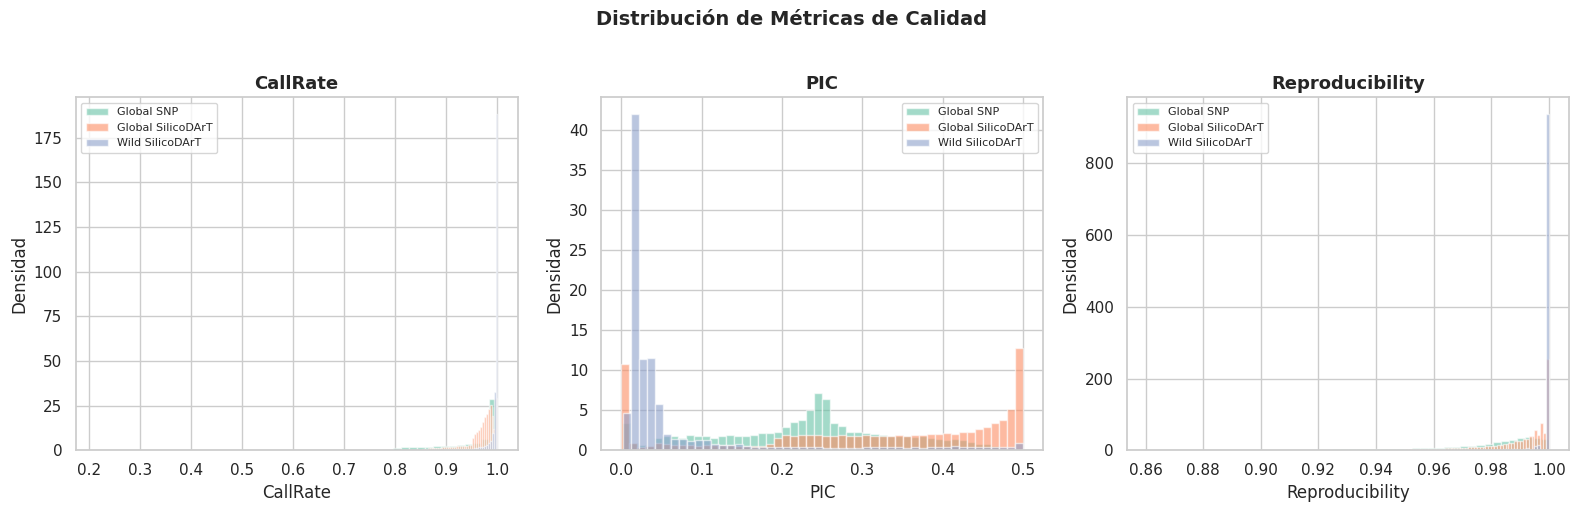

/tmp/ipykernel_115014/1000479121.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,
/tmp/ipykernel_115014/1000479121.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,
/tmp/ipykernel_115014/1000479121.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,


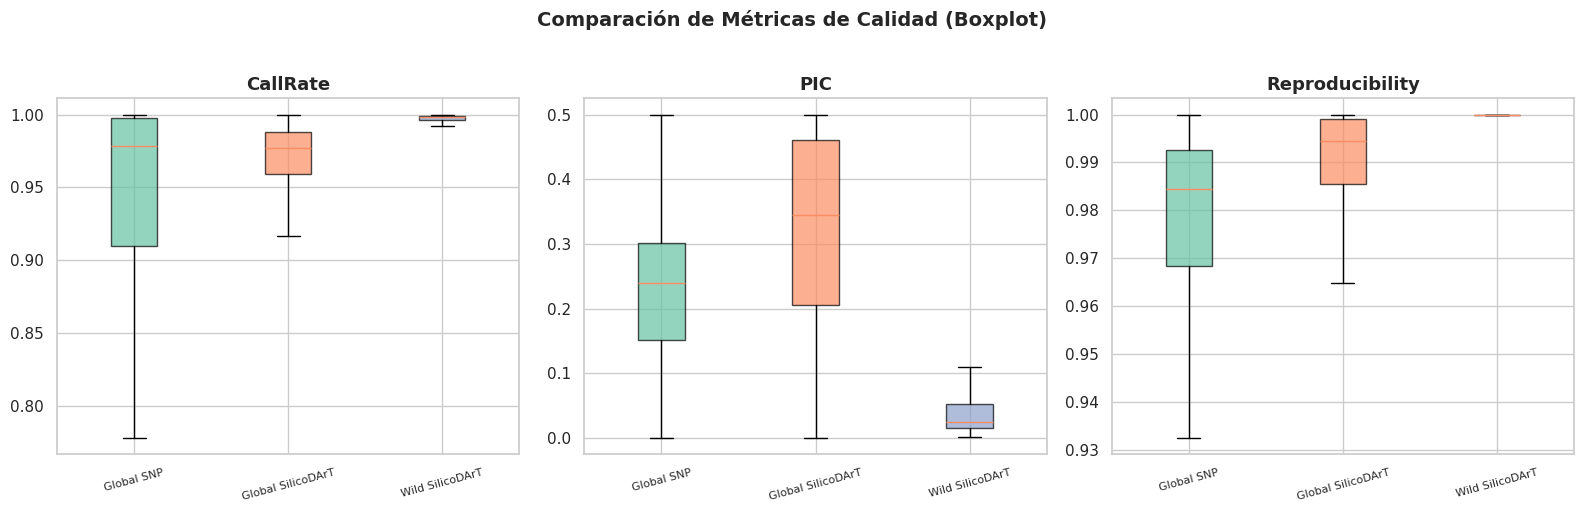

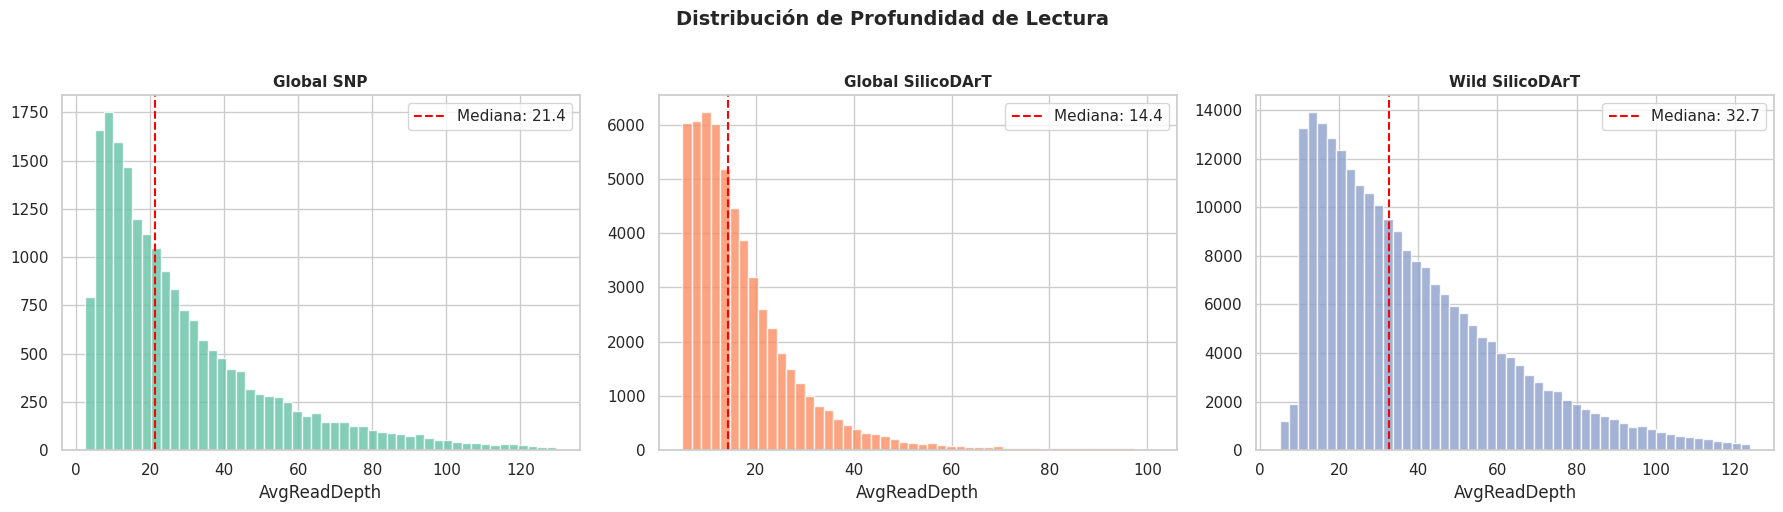

In [10]:
# Distribuciones de CallRate, PIC, Reproducibility
plot_metrics = ["CallRate", "PIC", "Reproducibility"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(plot_metrics):
    ax = axes[i]
    has_data = False
    for name, df in datasets_metrics.items():
        if metric in df.columns:
            vals = pd.to_numeric(df[metric], errors="coerce").dropna()
            if len(vals) > 0:
                ax.hist(vals, bins=50, alpha=0.6, label=name, density=True)
                has_data = True
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xlabel(metric)
    ax.set_ylabel("Densidad")
    if has_data:
        ax.legend(fontsize=8)

plt.suptitle("Distribución de Métricas de Calidad", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "outputs" / "quality_histograms.png", dpi=100, bbox_inches="tight")
plt.show()

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(plot_metrics):
    ax = axes[i]
    plot_data, labels = [], []
    for name, df in datasets_metrics.items():
        if metric in df.columns:
            vals = pd.to_numeric(df[metric], errors="coerce").dropna()
            if len(vals) > 0:
                plot_data.append(vals.values)
                labels.append(name)
    if plot_data:
        bp = ax.boxplot(plot_data, tick_labels=labels, patch_artist=True,
                        boxprops=dict(alpha=0.7), showfliers=False)
        colors = sns.color_palette("Set2", len(plot_data))
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=15, labelsize=8)

plt.suptitle("Comparación de Métricas de Calidad (Boxplot)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "outputs" / "quality_boxplots.png", dpi=100, bbox_inches="tight")
plt.show()

# AvgReadDepth distribution (solo para los que la tienen)
n_with_depth = sum(1 for df in datasets_metrics.values() if "AvgReadDepth" in df.columns)
if n_with_depth > 0:
    fig, axes = plt.subplots(1, n_with_depth, figsize=(6 * n_with_depth, 5))
    if n_with_depth == 1:
        axes = [axes]
    idx = 0
    for name, df in datasets_metrics.items():
        if "AvgReadDepth" in df.columns:
            vals = pd.to_numeric(df["AvgReadDepth"], errors="coerce").dropna()
            clipped = vals[vals < vals.quantile(0.99)]
            ax = axes[idx]
            ax.hist(clipped, bins=50, color=sns.color_palette("Set2")[idx], alpha=0.8)
            ax.axvline(vals.median(), color="red", ls="--", label=f"Mediana: {vals.median():.1f}")
            ax.set_title(name, fontsize=11, fontweight="bold")
            ax.set_xlabel("AvgReadDepth")
            ax.legend()
            idx += 1
    plt.suptitle("Distribución de Profundidad de Lectura", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(DATA_DIR / "outputs" / "read_depth_histograms.png", dpi=100, bbox_inches="tight")
    plt.show()

## 8. Missingness en Archivos de Genotipos

Para los archivos de genotipos (grandes, hasta 658 MB), leemos una muestra de filas
y estimamos el porcentaje de datos faltantes (`-`, `NaN`, vacíos).

📂 Archivos de genotipos a muestrear: 5

🔍 Sweetpotato low-density DArTSeq — 01_Report_DSp25-515_SNPs_Filtered_by _re
  Columnas muestra: 635, Missingness: 17.6%
🔍 Sweetpotato low-density DArTSeq — 02_Report_DSp25-515_Silico-DArT_Filtered
  Columnas muestra: 635, Missingness: 9.1%
🔍 Sweetpotato diversidad global NGS — SNP_Genotypes.csv
  Columnas muestra: 5970, Missingness: 8.0%
🔍 Sweetpotato diversidad global NGS — SilicoDArT_Genotypes.csv
  Columnas muestra: 5970, Missingness: 2.4%
🔍 Sweetpotato wild relatives — 01_Report_DSp25-515_SNPs_Filtered_by _re
  Columnas muestra: 635, Missingness: 17.6%



,Dataset,N muestras (cols),Filas leídas,Missingness (%)
0,Sweetpotato low-density DArTSeq — 01_Report_DS...,635,500,17.6
1,Sweetpotato low-density DArTSeq — 02_Report_DS...,635,500,9.1
2,Sweetpotato diversidad global NGS — SNP_Genoty...,5970,500,8.0
3,Sweetpotato diversidad global NGS — SilicoDArT...,5970,500,2.4
4,Sweetpotato wild relatives — 01_Report_DSp25-5...,635,500,17.6


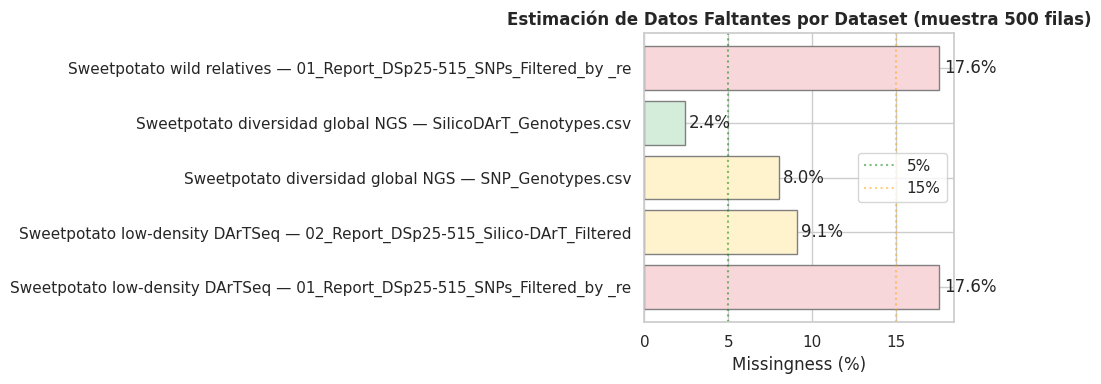

In [12]:
# Identificar archivos de genotipos (Genotype o Report en el nombre)
genotype_files = {}
for _, row in df_files.iterrows():
    fname = row["Archivo"]
    if row["Extensión"] != ".csv":
        continue
    if "Genotype" in fname or "Report" in fname:
        label = f"{row['Cultivo']} {row['Dataset']} — {fname[:40]}"
        genotype_files[label] = Path(row["path"])

# También incluir archivos de Yacon si fueron descargados
yacon_dir = DATA_DIR / YACON_FOLDER
if yacon_dir.exists():
    for fp in yacon_dir.glob("*.csv"):
        if "metric" not in fp.name.lower():
            # Podría ser un archivo de genotipos
            label = f"Yacon — {fp.name[:40]}"
            genotype_files[label] = fp

print(f"📂 Archivos de genotipos a muestrear: {len(genotype_files)}\n")

miss_results = []
for name, path in genotype_files.items():
    print(f"🔍 {name}")
    try:
        sep = detect_sep(path)
        sample = pd.read_csv(path, sep=sep, nrows=500, low_memory=False)

        # Identificar columnas de muestras (no son métricas)
        sample_cols = [
            c for c in sample.columns
            if not any(k in c.lower() for k in META_KW)
            and c != sample.columns[0]  # skip first col (puede ser label)
        ]

        if len(sample_cols) < 10:
            # Intentar con columnas que empiezan con dígito
            sample_cols = [c for c in sample.columns if c and c[0].isdigit()]

        if len(sample_cols) > 5:
            geno_data = sample[sample_cols]
            total_cells = geno_data.size
            missing_dash = (geno_data == "-").sum().sum()
            missing_nan = geno_data.isna().sum().sum()
            missing_empty = (geno_data == "").sum().sum()
            missing_total = missing_dash + missing_nan + missing_empty
            miss_pct = (missing_total / total_cells) * 100

            print(f"  Columnas muestra: {len(sample_cols)}, Missingness: {miss_pct:.1f}%")
            miss_results.append({
                "Dataset": name,
                "N muestras (cols)": len(sample_cols),
                "Filas leídas": len(sample),
                "Missingness (%)": round(miss_pct, 1),
            })
        else:
            print(f"  ⚠️ Pocas columnas de muestra ({len(sample_cols)})")
    except Exception as e:
        print(f"  ❌ Error: {e}")

print()
df_miss = pd.DataFrame(miss_results)
display(df_miss)

# Barchart de missingness
if len(df_miss) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ["#d4edda" if v < 5 else "#fff3cd" if v < 15 else "#f8d7da" for v in df_miss["Missingness (%)"]]
    bars = ax.barh(df_miss["Dataset"], df_miss["Missingness (%)"], color=colors, edgecolor="gray")
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_xlabel("Missingness (%)")
    ax.set_title("Estimación de Datos Faltantes por Dataset (muestra 500 filas)", fontweight="bold")
    ax.axvline(5, color="green", ls=":", alpha=0.5, label="5%")
    ax.axvline(15, color="orange", ls=":", alpha=0.5, label="15%")
    ax.legend()
    plt.tight_layout()
    plt.savefig(DATA_DIR / "outputs" / "missingness_barchart.png", dpi=100, bbox_inches="tight")
    plt.show()

# Markdown
md_sections.append("## 7. Missingness en Genotipos (estimación por muestreo)\n\n")
if len(df_miss) > 0:
    md_sections.append(df_miss.to_markdown(index=False) + "\n\n")

## 9. Tabla Resumen Consolidada

Integramos toda la información en una tabla final por dataset:
cultivo, tipo, DOI, status, dimensiones, missingness, genoma de referencia, CallRate promedio.

In [13]:
# Construir tabla consolidada
summary_rows = []
for crop, datasets in metadata.items():
    for ds in datasets:
        restricted = ds.get("restricted", False)
        folder = ds.get("folder")
        folder_exists = (DATA_DIR / folder).exists() if folder else False
        
        if restricted:
            status = "🔒 Restringido"
        elif folder_exists:
            status = "✅ Descargado"
        elif folder:
            status = "⚠️ Sin carpeta"
        else:
            status = "🌐 Accesible"
        
        # Buscar archivos
        n_files = 0
        total_size = 0
        if folder and folder_exists:
            folder_path = DATA_DIR / folder
            for f in folder_path.iterdir():
                if f.is_file():
                    n_files += 1
                    total_size += f.stat().st_size / (1024 * 1024)
        
        # Buscar genoma de referencia
        ref = "—"
        if folder_exists:
            matches = df_refs[df_refs["Dataset"] == ds["type"]]
            if len(matches) > 0:
                refs_found = matches[matches["Genoma Ref"] != "—"]["Genoma Ref"].unique()
                if len(refs_found) > 0:
                    ref = refs_found[0]
        
        summary_rows.append({
            "Cultivo": crop,
            "Tipo": ds["type"],
            "DOI": ds["doi"].split("/P3/")[-1] if "/P3/" in ds["doi"] else ds["doi"],
            "Status": status,
            "Archivos": n_files if n_files > 0 else "—",
            "Tamaño (MB)": round(total_size, 1) if total_size > 0 else "—",
            "Genoma Ref": ref,
        })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

# Estadísticas rápidas
print(f"\n📊 Resumen:")
print(f"  Datasets totales: {len(df_summary)}")
print(f"  Descargados: {(df_summary['Status'] == '✅ Descargado').sum()}")
print(f"  Accesibles (no descargados): {(df_summary['Status'] == '🌐 Accesible').sum()}")
print(f"  Restringidos: {(df_summary['Status'] == '🔒 Restringido').sum()}")

# Markdown
md_sections.append("## 8. Tabla Resumen Consolidada\n\n")
md_sections.append(df_summary.to_markdown(index=False) + "\n\n")

,Cultivo,Tipo,DOI,Status,Archivos,Tamaño (MB),Genoma Ref
0,Sweetpotato,low-density DArTSeq,UBDJ44,✅ Descargado,2,150.2,—
1,Sweetpotato,DArTag 3.1K amplicones,D3XEEH,🔒 Restringido,—,—,—
2,Sweetpotato,diversidad global NGS,S2IMOS,✅ Descargado,4,906.4,SweetPotato_unkn_v4
3,Sweetpotato,wild relatives,3VYY8C,✅ Descargado,3,153.4,SweetPotato_NSP323_v3
4,Yacon,SNP,JW6UOC,🔒 Restringido,—,—,—
5,Yacon,SilicoDArT,5KHIK4,🔒 Restringido,—,—,—
6,Ulluco,300 accesiones SNP,CD01KI,🔒 Restringido,—,—,—
7,Ulluco,300 accesiones SilicoDArT,IXXW5N,🔒 Restringido,—,—,—
8,Ulluco,68 accesiones in situ SilicoDArT,FYYLLO,🔒 Restringido,—,—,—
9,Oca,56 accesiones in situ SilicoDArT,M613LS,🔒 Restringido,—,—,—



📊 Resumen:
  Datasets totales: 11
  Descargados: 3
  Accesibles (no descargados): 0
  Restringidos: 8


## 10. Exportar DATA_CATALOG.md

Generamos el markdown de forma programática para que siempre sea consistente con los datos.
Re-ejecutar este notebook regenera el archivo automáticamente.

In [14]:
# Construir el markdown final
header = f"""# 🧬 DATA_CATALOG — OXOR / GENO-MAP

> **Generado automáticamente** por `notebooks/data_catalog.ipynb`  
> **Fecha:** {datetime.now().strftime('%Y-%m-%d %H:%M')}  
> **Fuente de datos:** [CIP Dataverse](https://data.cipotato.org)

---

"""

# TL;DR al inicio
n_descargados = (df_summary["Status"] == "✅ Descargado").sum()
n_restringidos = (df_summary["Status"] == "🔒 Restringido").sum()
n_accesibles = (df_summary["Status"] == "🌐 Accesible").sum()

tldr = f"""## TL;DR

- **Universo:** {len(df_universo)} datasets escaneados del CIP Dataverse (últimos 100 publicados)
- **Catálogo curado:** {len(df_summary)} datasets de genotipado de {df_summary['Cultivo'].nunique()} cultivos andinos
- **Descargados localmente:** {n_descargados} datasets ({df_files['Tamaño (MB)'].sum():.0f} MB total)
- **Restringidos:** {n_restringidos} datasets (publicados pero requieren permisos CIP)
- **Accesibles sin descargar:** {n_accesibles}
- **Genomas de referencia:** {', '.join(refs_unique) if len(refs_unique) > 0 else 'por determinar'}
"""

if len(refs_unique) > 1:
    tldr += "- ⚠️ **Múltiples genomas de referencia**: integración cruzada requiere re-mapeo\n"

tldr += "\n---\n\n"

# Ensamblar documento completo
catalog_md = header + tldr + "".join(md_sections)

# Agregar sección de datasets restringidos
catalog_md += """## 9. Nota sobre Datasets Restringidos

Los siguientes datasets están **publicados públicamente** en el CIP Dataverse
(sus DOIs son accesibles y sus metadatos son visibles), pero la **descarga de archivos
requiere autorización** del Centro Internacional de la Papa (CIP):

"""
for _, row in df_summary[df_summary["Status"] == "🔒 Restringido"].iterrows():
    catalog_md += f"- **{row['Cultivo']}** — {row['Tipo']} (`{row['DOI']}`)\n"

catalog_md += """
Estos datasets son relevantes para el proyecto y podrían incorporarse en el futuro
si se obtienen los permisos correspondientes.

---

## 10. Estructura de Carpetas

```
data/
├── cipotato_datasets_latest100.json    # Universo: 100 datasets CIP Dataverse
├── metadata.json                        # Catálogo curado: 11 datasets seleccionados
├── DATA_CATALOG.md                      # Este archivo (generado por notebook)
"""

for ds_info in disponibles:
    folder = ds_info["folder"]
    catalog_md += f"├── {folder.name}/\n"
    if folder.exists():
        for f in sorted(folder.iterdir()):
            if f.is_file():
                size_mb = f.stat().st_size / (1024 * 1024)
                catalog_md += f"│   ├── {f.name} ({size_mb:.0f} MB)\n"

catalog_md += """└── outputs/
    └── *.json, *.png                    # Artefactos generados
```
"""

# Escribir archivo
output_path = DATA_DIR / "DATA_CATALOG.md"
with open(output_path, "w") as f:
    f.write(catalog_md)

print(f"✅ Exportado: {output_path}")
print(f"   Tamaño: {len(catalog_md):,} caracteres, {catalog_md.count(chr(10)):,} líneas")
display(Markdown("---\n### Vista previa (primeras 80 líneas):\n\n" + "\n".join(catalog_md.split("\n")[:80])))

✅ Exportado: ../data/DATA_CATALOG.md
   Tamaño: 17,422 caracteres, 185 líneas


---
### Vista previa (primeras 80 líneas):

# 🧬 DATA_CATALOG — OXOR / GENO-MAP

> **Generado automáticamente** por `notebooks/data_catalog.ipynb`  
> **Fecha:** 2026-03-01 00:27  
> **Fuente de datos:** [CIP Dataverse](https://data.cipotato.org)

---

## TL;DR

- **Universo:** 100 datasets escaneados del CIP Dataverse (últimos 100 publicados)
- **Catálogo curado:** 11 datasets de genotipado de 5 cultivos andinos
- **Descargados localmente:** 3 datasets (1210 MB total)
- **Restringidos:** 8 datasets (publicados pero requieren permisos CIP)
- **Accesibles sin descargar:** 0
- **Genomas de referencia:** SweetPotato_unkn_v4, SweetPotato_NSP323_v3
- ⚠️ **Múltiples genomas de referencia**: integración cruzada requiere re-mapeo

---

## 1. Universo CIP Dataverse
- **Total datasets escaneados:** 100
- **Relacionados con genotipado:** 20
- **Seleccionados para este proyecto:** 11

### Datasets de genotipado detectados

| doi_code   | title                                                                                                                                                                                                          | fecha      | en_catalogo   |
|:-----------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------|:--------------|
| nan        | Dataset for: At least 20 advanced clones from LBHTxLTVR population with resistance to late blight, virus, heat and drought tolerance, high tuber yield and quality for french fries and/or chips and earliness | 2026-01-28 | False         |
| FFORMJ     | Dataset for: Advanced clones of group B3 cycle 3, population B with late blight resistance in Oxapampa, 2014                                                                                                   | 2026-01-28 | False         |
| OTYRIV     | Dataset for: Advanced clones of group B3 cycle 3, population B with late blight resistance in Oxapampa, 2012                                                                                                   | 2026-01-28 | False         |
| LCGD4P     | Dataset for: Advanced clones of group B3 cycle 3, population B with late blight resistance in Oxapampa, 2013                                                                                                   | 2026-01-28 | False         |
| 3VYY8C     | Replication data for: Genetic Diversity Analysis of a large collection of sweetpotato wild relatives, Ipomoea spp.                                                                                             | 2026-01-28 | True          |
| UBDJ44     | Dataset for: Genotyping of sweetpotato genebank accessions using low-density DArTSeq markers                                                                                                                   | 2026-01-28 | True          |
| SFXXDC     | Dataset for: Advanced clones of  B3C0, group B3, population B in Oxapampa-Peru                                                                                                                                 | 2026-01-27 | False         |
| TNNRYW     | Dataset for: Advanced clones of  B3C0, group B3, population B in Comas-Peru                                                                                                                                    | 2026-01-27 | False         |
| JW6UOC     | Dataset for: High density genotyping of cultivated yacon genebank accessions using SNP markers from DArTseq                                                                                                    | 2026-01-27 | True          |
| 5KHIK4     | Dataset for: High density genotyping of cultivated yacon genebank accessions using SilicoDArT markers                                                                                                          | 2026-01-27 | True          |
| CD01KI     | Dataset for: High density genotyping of cultivated ullucus genebank accessions using SNP markers from DArTseq                                                                                                  | 2026-01-27 | True          |
| IXXW5N     | Dataset for: High density genotyping of cultivated ullucus genebank accessions using SilicoDArT markers                                                                                                        | 2026-01-27 | True          |
| FYYLLO     | Dataset for: Genotypic Dataset of In Situ Native Ulluco Varieties from the Andenes de Cuyocuyo Agrobiodiversity Zone using SilicoDArT markers                                                                  | 2026-01-27 | True          |
| M613LS     | Dataset for: Genotypic Dataset of In Situ Native Oca Varieties from the Andenes de Cuyocuyo Agrobiodiversity Zone using SilicoDArT markers                                                                     | 2026-01-27 | True          |
| TFOJNZ     | Dataset for: Genotypic Dataset of In Situ Native Mashua Varieties from the Andenes de Cuyocuyo Agrobiodiversity Zone using SilicoDArT markers                                                                  | 2026-01-27 | True          |
| EKOYZ1     | Dataset for: Heritability for yield components in LBHT potato clones, under warm conditions                                                                                                                    | 2026-01-27 | False         |
| D3XEEH     | Dataset for: Genotyping of sweetpotato genebank accessions using amplicon-based targeted markers (DArTag)                                                                                                      | 2025-12-31 | True          |
| RUTCZH     | Dataset for: Characterization database of 36 genotypes of native potatoes of the andigenum group from the Cumbal Indigenous Reservation - 2025                                                                 | 2025-12-31 | False         |
| HVXVLB     | Dataset for: Characterization database of 64 genotypes of native potatoes of the Phurejas group from the Cumbal Indigenous Reservation - 2025                                                                  | 2025-12-17 | False         |
| S2IMOS     | Replication data for: Revealing the genetic diversity in the global ex situ sweetpotato collection with next generation sequencing technologies.                                                               | 2025-12-17 | True          |

## 2. Catálogo Curado (metadata.json)

**11 datasets** de **5 cultivos**: Sweetpotato, Yacon, Ulluco, Oca, Mashua

| Status | Cantidad |
|--------|----------|
| 🔒 Restringido | 8 |
| ✅ Descargado | 3 |

| Cultivo     | Tipo                             | DOI                                | Status         |
|:------------|:---------------------------------|:-----------------------------------|:---------------|
| Sweetpotato | low-density DArTSeq              | https://doi.org/10.21223/P3/UBDJ44 | ✅ Descargado  |
| Sweetpotato | DArTag 3.1K amplicones           | https://doi.org/10.21223/P3/D3XEEH | 🔒 Restringido |
| Sweetpotato | diversidad global NGS            | https://doi.org/10.21223/P3/S2IMOS | ✅ Descargado  |
| Sweetpotato | wild relatives                   | https://doi.org/10.21223/P3/3VYY8C | ✅ Descargado  |
| Yacon       | SNP                              | https://doi.org/10.21223/P3/JW6UOC | 🔒 Restringido |
| Yacon       | SilicoDArT                       | https://doi.org/10.21223/P3/5KHIK4 | 🔒 Restringido |
| Ulluco      | 300 accesiones SNP               | https://doi.org/10.21223/P3/CD01KI | 🔒 Restringido |
| Ulluco      | 300 accesiones SilicoDArT        | https://doi.org/10.21223/P3/IXXW5N | 🔒 Restringido |
| Ulluco      | 68 accesiones in situ SilicoDArT | https://doi.org/10.21223/P3/FYYLLO | 🔒 Restringido |
| Oca         | 56 accesiones in situ SilicoDArT | https://doi.org/10.21223/P3/M613LS | 🔒 Restringido |
| Mashua      | 28 accesiones in situ SilicoDArT | https://doi.org/10.21223/P3/TFOJNZ | 🔒 Restringido |

## 3. Inventario de Archivos Locales

**9 archivos**, **1210 MB** (1.2 GB)

| Cultivo     | Dataset               | Archivo                                               |   Tamaño (MB) |
|:------------|:----------------------|:------------------------------------------------------|--------------:|
| Sweetpotato | low-density DArTSeq   | 01_Report_DSp25-515_SNPs_Filtered_by _reads.csv       |          96.3 |